# Quantum Dynamics and Device Simulation
  * Brandon Lippe
  * Patrick Kollias
  * Lauren Lozano
  * Sinai Gallegos
  

# Closed vs. Open Systems in Quantum Dynamics

* Closed System(Unitary) - Nucleus of a Hydrogen atom, Entanglement. Schroedinger Equation
* Open System(Non-Unitary) - Electron Cloud's interactions with the environment, Decoherence.
* 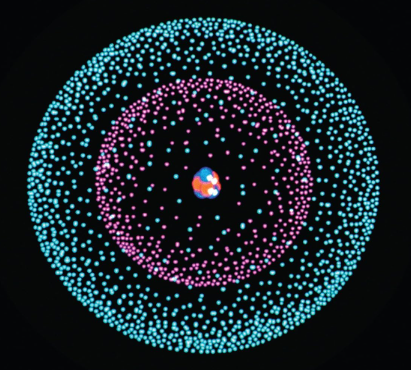

Image from The Atom: A Visual Tour - Jack Challoner



# The Lindblad equation – Open Systems

We’ve assumed the system is perfectly isolated. In reality, that’s almost never true. Systems interact with their environment, and that completely changes the dynamics.

**Lindblad equation** [1][3]:

$$
\frac{d\rho}{dt} = -\frac{i}{\hbar}[H,\rho(t)] + \sum_n \frac{1}{2} \gamma_n \left( 2L_n \rho(t) L_n^\dagger - \rho(t) L_n^\dagger L_n -  L_n^\dagger L_n \rho(t)  \right)
$$

**First term**:

- Same as before

**Second term**:

- environment effects  
- $L_n$ = **jump operators**  
- $\gamma_n$ = **relaxation/dephasing rates**  

The system evolves by:

- **smooth phase evolution**  
- **random jumps / decoherence**  

**Assumptions**

This equation only works if:

- **weak coupling**  
- **environment is large**  
- **Markovian (no memory)**  
- **fast environment dynamics** [1]

Each Lindblad operator represents a **physical process** like relaxation or dephasing, and the rates determine how quickly **coherence is lost**.

$$\rho_{\text{decohering}}= \begin{bmatrix} \text{Population of }|0\rangle & \text{Decaying Coherence} \\ \text{Decaying Coherence} & \text{Population of }|1\rangle \end{bmatrix}$$

One of the most important effects of this is that the off-diagonal elements of the density matrix decay over time.

In a simple two-level system, you might see oscillations in a closed system.
But once you include Lindblad terms, those oscillations decay and the system eventually settles into a steady state.

| Approximation | Core Assumption | Physical Meaning & Consequence |
| :--- | :--- | :--- |
| **Born** | Environment state unchanged; system and environment remain separable: $\rho_{tot}(t) \approx \rho(t) \otimes \rho_{env}(t)$ | Weak coupling; environment much larger than system |
| **Markov** | Environment decay timescale much shorter than system dynamics: $\tau_{sys} \gg \tau_{env}$ | "Short-memory" environment; rapid decay of environmental correlations |
| **Secular** | Fast-rotating terms in the master equation can be neglected | Ignores small energy renormalization; required for Lindblad form (not needed for Bloch-Redfield) |

## Section 3 - Heisenberg Model with a time-varying magnetic field
In this section  we will now look at a much larger quantum system, considering a 1-D chain of 10 spins according to the Heisenberg Hamiltonian, adding a time-dependent transverse magnetic field after a delay. We can use this system to model quantum quench dynamics.

$\hat H = J_{ij}\sum S_i \cdot S_j + B_x (t) \sum \sigma^x_i $

 For this example, we consider the case where the $\sigma^z_i \sigma^z_{i+1}$ coupling is dominant, and prepare the system in an alternating spin up and down state, the approximate ground state.

 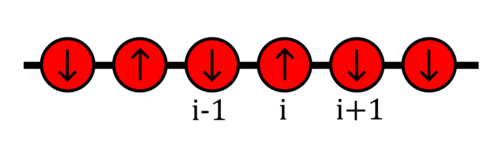

 * In physics Paramagnetism is modelled quantum mechanically as an energy term proportional to μB⋅(L +gS)
 * This Hamiltonian is used to study Spontaneous magnetic order of different types of magnetism, paramagnetism, ferromagnetism, etc.
 * Pauli Operators σ represent the spin state of electrons or spin-1/2 objects while S is the general spin operator representing the intrinsic angulur momentum of an atomic object. The NV center, Carbon-14 carry a spin of S=1, Carbon-13 is spin 1/2.
 * Heisenberg model is more general than the Ising model in that the spins S are allowed to point in any direction rather than a preferred direction along the zed axis.




# Applications:
* Used in fields such as: photochemistry, condensed-phase physics, nanoscience,
molecular electronics, quantum optics, spectroscopy and quantum information processing, etc.

* Nitrogen Vacancy(NV$^-$) Centers
* NV$^-$ Center's environment is dominated by the physics inside of a crystal lattice.
* Coherence time($T_2^*$) is limited by slowly fluctuation magnetic fields from the nuclear spin bath
* Qubits can be formed with the NV electron via nuclear spins in the diamond lattice(10+ qubits have been demonstrated) with an analogy of the 'quantum bus'.
* Two-qubit gates engineered between a NV electron and nearby Carbon-13 nuclear spin via Spin-Spin interaction(Hyperfine).

* 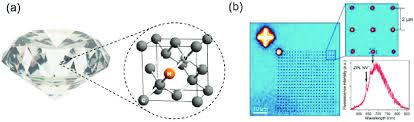


# Chemical Dynamics Simulations

The **Central equation** is the **time-dependent Schrodinger equation** [3]

$$
i\hbar \frac{d}{dt} |\psi(t)\rangle = \hat{H} |\psi(t)\rangle
$$

**What it means physically**:

- $|\psi(t)\rangle$ : the **quantum state at time t**  
- $\hat{H}$ : **Hamiltonian = total energy operator**  


This equation tells you **how the system evolves**

If it is time independent, it becomes an operator called **propagator** [3]

$$
|\psi(\tau)\rangle = e^{-i\hat{H}\tau/\hbar} |\psi(0)\rangle
$$

- You start with an **initial state** $|\psi(0)\rangle$  
- You apply a **unitary operator**  
- You get the **future state**  

But computationally, this is extremely hard, because exponentiating a large operator is expensive.

Instead of solving this differential equation directly, we rewrite it as an operator acting on the initial state. This is important because now the entire problem becomes: **how do we efficiently apply this operator?**

We are trying to preserve, update, approximate, or model the way phase information changes over time.

# What we compute

**Autocorrelation function**

$$
\xi(t) = \langle \psi_0 | \psi(t) \rangle
$$

**How similar is the state now vs initial?**

**Expectation value**

$$
\langle O \rangle = \langle \psi(t) | \hat{O} | \psi(t) \rangle
$$

- What is the **measured value** of observable O?  
- The **wavefunction is not directly observable**  
- **Observables come from expectation values** [3]

So all of our simulation methods are really about evolving the state in a way that lets us compute these quantities accurately.

# Simulations on Classical Computers

How do we actually compute this on a real computer?

- That’s where **classical simulation methods** come in.

What are we doing here?

- We want to **numerically solve Schrödinger equation**

**Steps**:

1. Represent the wavefunction  
2. Apply time evolution  
3. compute observables  

**Two approaches introduced** [1]:

1. **SOFT (Split Operator Fourier Transform)**  
2. **QuTiP (matrix method)**  

| SOFT                | QuTiP               |
|---------------------|---------------------|
| Position basis      | Energy basis        |
| Uses FFT            | Uses matrix ops     |
| More physical intuition | More abstract   |

# SOFT Method

We want to compute [1]:

$$
e^{-i H \tau}
$$

BUT:

$$
H = T + V
$$

And in our system $$V(x) = \frac{1}{2} m \omega^2 x^2  $$
$$ T(p) = \frac{p^2}{2m}$$

**T and V don’t commute**

So we approximate using **Trotter decomposition** [1][3]:

$$
e^{-iH\tau}
=
e^{-\frac{i}{\hbar} V(x)\tau/2}
\;
e^{-\frac{i}{\hbar} \frac{p^2}{2m} \tau}
\;
e^{-\frac{i}{\hbar} V(x)\tau/2}
+ \mathcal{O}(\tau^3)
$$

This works because **T is diagonal in momentum space** and **V is diagonal in position space**, so we switch between bases using **Fourier transforms** [1].

- approximation becomes exact in the limit of **small timesteps**  
- error scales with the **commutator of T and V**  

**Quantum Dynamics Simulation Loop**

Each timestep:

1. Apply potential (**position space**)  
2. Fourier transform → **momentum space**  
3. Apply kinetic  
4. Inverse Fourier transform  
5. Apply potential again  

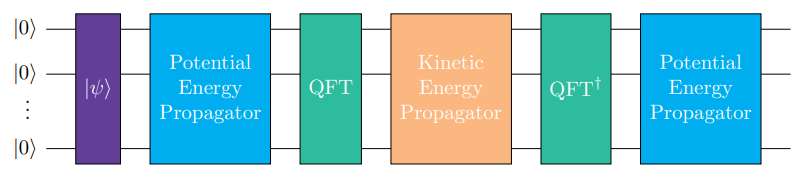

obtained from ref [1]

The error comes from the fact that the operators do not commute, and that error decreases as we make the timestep smaller. There’s always a tradeoff between accuracy and computational cost.

# QuTiP Method

SOFT gives us a very physical picture, but there’s another that allows us to use **matrices** and letting a **solver handle it** [1][2].

Here we show an example of the initial state in the **Fock basis (energy eigenstates)**

Initial state:

$$
|\alpha\rangle = e^{-|\alpha|^2 / 2} \sum_n \frac{\alpha^n}{\sqrt{n!}} |n\rangle
$$

This is a **coherent state**

Hamiltonian:

$$
H = \hbar \omega (\hat{a}^\dagger \hat{a} + \frac{1}{2})
$$

**Standard quantum harmonic oscillator**

This method is especially useful when the system does not have a clean spatial interpretation, or when dissipation and open-system effects need to be added directly.

                          
# Quantum SOFT

**Classical SOFT**:

- apply V  
- Fourier transform  
- apply T  
- inverse Fourier  

**Quantum version**:

- apply **phase gate for V**  
- apply **Quantum Fourier Transform (QFT)**  
- apply **phase gate for T**  
- apply **inverse QFT**  [1][3]

Again, we want:

$$
e^{-iHt}
$$

But **H = A + B and they don’t commute**

So, we use the **Trotter approximation again** [3]
                          
In many systems, including spin systems, the Hamiltonian can be written as a sum of Pauli operators. [2][3]

$$
H = J \sum_{\langle i,j \rangle} \left( X_i X_j + Y_i Y_j + Z_i Z_j \right)
$$
                          

# Classical Simulation of Lindblad: Two Main Methods

**Matrix Exponential Method**

$$
\rho \rightarrow v_\rho \qquad \frac{d}{dt} v_\rho = (A_C + A_D)\, v_\rho
$$

The key effect of the Lindblad term is that it causes the **off-diagonal elements** of the density matrix—representing **coherence**—to **decay over time**.

- $A_C$ = **coherent part**  
- $A_D$ = **dissipative part** [1]

The solution becomes:

$$
v_\rho(t) = G(t)v_\rho(0)= e^{(A_C + A_D)t} \, v_\rho(0)
$$

where $G(t)$ is the propagator.

**QuTiP Method**

Use:

- `mesolve()` [2]  

You provide:

- Hamiltonian  
- initial state  
- collapse operators $\sqrt{\gamma_n} L_n$  

If you don’t include collapse operators you get **closed system (Liouville equation)**

If you include them you get **Lindblad dynamics**

The challenge here is that density matrices are larger than state vectors, so the memory and computational cost typically increase.

# Quantum Simulation of Open Systems

- the trick is to embed the **non-unitary evolution** into a larger **unitary system** by adding extra qubits. This effectively lets us simulate the environment. [1]

- Quantum computers only do **unitary (reversible) operations** but Lindblad is **non-unitary**

- This works because any non-unitary evolution can be represented as a **unitary evolution in a larger Hilbert space**

- The solution is to convert **non-unitary → unitary** using **Sz. –Nagy dilation** [1]

- Take a **non-unitary operator $G(t)$**

- Embed it into a bigger **unitary matrix:** $$U_M =
\begin{pmatrix}
M & D_{M^\dagger} \\
D_M & -M^\dagger
\end{pmatrix}
\quad \text{where} \quad
D_M = \sqrt{I - M^\dagger M}, \quad
D_{M^\dagger} = \sqrt{I - M M^\dagger}$$


**What this means physically**

- add **ancilla qubits**  
- simulate **environment implicitly**

# Quantum Algorithm for Lindblad (Kraus Representation)

Another way to think about this is instead of continuous evolution, we model the system as undergoing **probabilistic jumps**, this is the **Kraus representation**. [1][3]

**Alternative formulation**

Instead of differential equation:

$$
\rho(t) = \sum_k M_k \rho(0) M_k^\dagger
$$

Where $M_k$ is a **Kraus operator = probabilistic processes**, so each $M_k$ is **one possible evolution path**

Apply repeatedly:

$$
\rho(t + \Delta t) = \sum_k M_k \rho(t) M_k^\dagger
$$

like **stochastic evolution**

This representation is useful because it connects naturally to noise channels used in quantum computing, such as bit-flip noise, phase-flip noise, or amplitude damping. [3]

# Shadow Analogy
https://www.youtube.com/watch?v=5fgOK0odA1o

# References

[1] Primary paper on chemical/open quantum system simulation used for presentation.

[2] Johansson, Nation, Nori. *QuTiP: Quantum Toolbox in Python.*

[3] Nielsen & Chuang. *Quantum Computation and Quantum Information.*

In [ ]:
# Instructions for Google Colab.

!pip install cudaq

!wget -q https://github.com/nvidia/cuda-q-academic/archive/refs/heads/main.zip
!unzip -q main.zip
!mv cuda-q-academic-main/dynamics101/images ./images

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.9/128.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 MB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.1/277.1 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.8 MB/s eta 0:00:00
  Created wheel for cudaq: filename=cudaq-0.14.0-py3-none-any.whl size=7829 sha256=b417c600f89db1283feda234abb1087320618b94bf7af29aa0d2a0837b4c749e
  Stored in directory: /root/.cache/pip/wheels/d1/6f/69/6c1c103b341ba72132776a334aae3a495fe8430de1fe00bb3e
Successfully built cudaq
  Attempting uninstall: cupy-cu

In [ ]:
import cudaq
from cudaq import spin, operators, ScalarOperator, Schedule, ScipyZvodeIntegrator
import numpy as np
import cupy as cp
import os
import matplotlib.pyplot as plt

In [ ]:
# Set the target to our dynamics simulator
cudaq.set_target("dynamics")

# In this example, we solve the Quantum Heisenberg model (https://en.wikipedia.org/wiki/Quantum_Heisenberg_model),
# which exhibits the so-called quantum quench effect.

# Number of spins
N = 10

dimensions = {}
for i in range(N):
    dimensions[i] = 2

# Initial state: alternating spin up and down
spin_state = ''
for i in range(N):
    spin_state += str(int(i % 2))



<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px; border-radius: 4px;">
    <h3 style="color: #76b900; margin-top: 0;"> Exercise  1 - Define a time-varying magnetic field:</h3>
    <p style="font-size: 16px; color: #333;">
Now, construct the Hamiltonian with a step function B-field that turns on with magnitude 2.0 after a time delay=2.5. Modify the `B_field` function below to reflect this.
    </p>
</div>


In [ ]:

# Define a time dependent B field
delay=2.5
def B_field(time):
    if abs(time)<delay:
        B=0.0
    else:
        B=2.0
    return B

# for delay =2.5s , magnetic(B) field is zero for less than delay, and B=Asin(omega*t), for A=2.0 T
#def B_field(time):
#    if time < 2.5:
#        return 0.0
#    else:
#        return 2.0 * np.sin(2 * np.pi * time)

Now add the magnetic field term to the Hamiltonian. Assume the B-field lies in the x direction. The spin-spin Hamiltonian terms are given already.

In [ ]:

# Heisenberg model spin coupling strength
Jx = -0.2
Jy = -0.2
Jz = -1.0

# Construct the Hamiltonian
H = operators.zero()

# Spin-spin terms
for i in range(N - 1):
    H += Jx * spin.x(i) * spin.x(i + 1)
    H += Jy * spin.y(i) * spin.y(i + 1)
    H += Jz * spin.z(i) * spin.z(i + 1)

# Magnetic Field terms
for i in range(N):
    H += ScalarOperator(B_field) * spin.x(i)

We can now execute the simulation, measuring the $\sigma^z_i$ expectation. Other common observables for this system are spin correlators $\langle \sigma^z_i \sigma^z_j \rangle$ and the magnetization $M = \frac{1}{N} \sum \langle\sigma^z_i\rangle$

In [ ]:
# Define the time schedule
steps = np.linspace(0.0, 5, 1000)
schedule = Schedule(steps, ["time"])

# Prepare the initial state vector
psi0_ = cp.zeros(2**N, dtype=cp.complex128)
psi0_[int(spin_state, 2)] = 1.0
psi0 = cudaq.State.from_data(psi0_)

# Run the simulation
evolution_result = cudaq.evolve(H,
                                dimensions,
                                schedule,
                                psi0,
                                observables=[spin.z(i) for i in range(N)],
                                collapse_operators=[],
                                store_intermediate_results=cudaq.IntermediateResultSave.EXPECTATION_VALUE,
                                integrator=ScipyZvodeIntegrator())


Text(0.5, 0, 'Time')

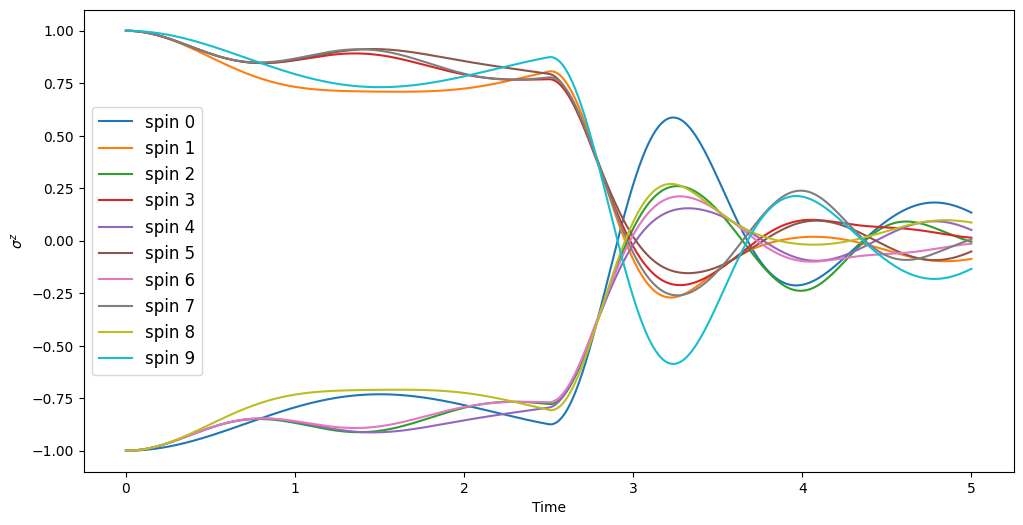

In [ ]:
# Plot the results
get_result = lambda idx, res: [
    exp_vals[idx].expectation() for exp_vals in res.expectation_values()
]

exp_val = [get_result(i, evolution_result) for i in range(N)]

# Plot the results
fig = plt.figure(figsize=(12, 6))
for i in range(N):
    plt.plot(steps, exp_val[i],label=f'spin {i}')
plt.legend(fontsize=12)
plt.ylabel(r"$\sigma^z$")
plt.xlabel("Time")



# Qiskit, QuTIP

In [ ]:
!pip install qiskit
!pip install qiskit_aer
!pip install qutip
import numpy as np
import scipy.linalg as sp
import matplotlib.pyplot as plt
import qiskit
from qiskit import *
from qiskit_aer import AerSimulator
from qiskit.quantum_info.operators import Operator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.1/33.1 MB 23.5 MB/s eta 0:00:00


In [ ]:
from qutip import mesolve, Qobj
import numpy as np

#the system Hamiltonian parameter
nsite = 3 #this states how many spins in the simulation
ndvr = 2**nsite #this is the dimension of the Hilbert space
Omegai_list = [0.65, 1.0, 1.0]
Jix_list = [0.75, 1.0]
Jiy_list = [0.75, 1.0]
Jiz_list = [0.0, 0.0]

spin_up = np.array([1.0,0.0],dtype=np.float64)
spin_down = np.array([0.0,1.0],dtype=np.float64)

#Pauli matries
sigmax = np.array([[0, 1], [1, 0]],dtype=np.complex128)
sigmaz = np.array([[1, 0], [0, -1]],dtype=np.complex128)
sigmay = np.array([[0, -1j], [1j, 0]],dtype=np.complex128)
ident = np.eye(2,dtype=np.complex128)

In [ ]:
#set up the initial state at [up,down,down...]
init_state = spin_up.copy()
for i in range(nsite-1):
  init_state = np.kron(init_state,spin_down)

#ste up the initial density matrix according to initial state
rho0 = np.zeros((ndvr,ndvr),dtype=np.complex128)
rho0 += np.outer(init_state,init_state.conj())

With the parameters above, we can define the spin chain Hamiltonian through the outer
product of the Pauli matrices constituting the Hamiltonian operators.

In [ ]:
# the diagnoal part of the Hamiltonian
H_diag = np.zeros((ndvr,ndvr),dtype=np.complex128)
for n in range(nsite):
  tmp_op = 1.0 # Initialize operator for current diagonal term
  for i in range(nsite):
    if(i==n):
      tmp_op = np.kron(tmp_op,sigmaz)
    else:
      tmp_op = np.kron(tmp_op,ident)
  H_diag += Omegai_list[n]*tmp_op # Add the fully constructed term to H_diag

# the non-diagnoal (coupling) part of the Hamiltonian
H_coup = np.zeros((ndvr,ndvr),dtype=np.complex128)
XX = np.kron(sigmax,sigmax)
YY = np.kron(sigmay,sigmay)
ZZ = np.kron(sigmaz,sigmaz)

for n in range(nsite-1): # Iterate over coupled pairs (n, n+1)
  # Create the 2-site coupling operator for the current pair
  couple_op_2site = Jix_list[n]*XX + Jiy_list[n]*YY + Jiz_list[n]*ZZ

  current_coupling_term_operator = 1.0

  # Tensor identities for spins before the coupled pair (0 to n-1)
  for i in range(n):
    current_coupling_term_operator = np.kron(current_coupling_term_operator, ident)

  # Tensor the 2-site coupling operator for spins n and n+1
  current_coupling_term_operator = np.kron(current_coupling_term_operator, couple_op_2site)

  # Tensor identities for spins after the coupled pair (n+2 to nsite-1)
  for i in range(n + 2, nsite):
    current_coupling_term_operator = np.kron(current_coupling_term_operator, ident)

  H_coup += current_coupling_term_operator # Add the fully constructed term to H_coup
hsys = H_diag - 0.5 * H_coup
hsys_qobj = Qobj(hsys)

In [ ]:
#The lindblad damping rate
Gamma1 = [2/24.9]*nsite
Gamma2 = [4/15.3]*nsite

Lindbladian = []
Lindbladian_qobj = []

sigmap = (sigmax+1j*sigmay)*0.5
sigmam = (sigmax-1j*sigmay)*0.5
sigma2 = sigmap@sigmam

for isite in range(nsite):
  #Lindbladian for type 1
  res = 1.0
  for j in range(nsite):
    if(j==isite):
     res = np.kron(res,sigmam)*np.sqrt(Gamma1[isite])
    else:
     res = np.kron(res,ident)
  Lindbladian.append(res)
  Lindbladian_qobj.append(Qobj(res))

  #Lindbladian for type 2
  res = 1.0
  for j in range(nsite):
    if(j==isite):
     res = np.kron(res,sigma2)*np.sqrt(Gamma2[isite])
    else:
     res = np.kron(res,ident)
  Lindbladian.append(res)
  Lindbladian_qobj.append(Qobj(res))

In [ ]:
vec_rho0 = rho0.reshape(ndvr**2)

#derivation matrix
ident_h = np.eye(ndvr, dtype = np.complex128)
Amat = -1j*(np.kron(hsys,ident_h)-np.kron(ident_h,hsys.T))

# the lindblad term
for i in range(len(Lindbladian)):
  Amat += (2.0*(np.kron(Lindbladian[i],Lindbladian[i].conj())) - np.kron(ident_h,
    Lindbladian[i].T@Lindbladian[i].conj()) -
    np.kron(Lindbladian[i].T.conj()@Lindbladian[i],ident_h))*0.5


# the propagator
dt = 0.1
nsteps = 250
Gprop = []
Prob_exp = np.zeros(nsteps,dtype=np.float64)
for i in range(nsteps):
  Gt = sp.expm(Amat*dt*i)
  Gprop.append(Gt)
  vec_rhot = Gt@vec_rho0
  survi_prob = np.sqrt((np.dot(vec_rho0.conj(),vec_rhot)).real)
  Prob_exp[i] = survi_prob

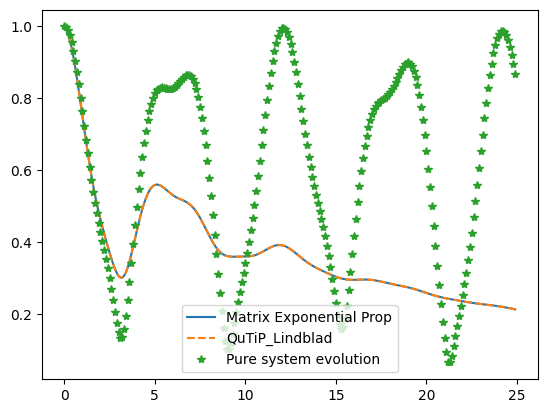

In [ ]:
from qutip import mesolve, Qobj

#time step
dt = 0.1
nsteps = 250

time = np.linspace(0,dt*(nsteps-1),nsteps)

rho0_qobj = Qobj(rho0)
#using QuTip to simulate the spin-chain Lindblad equation
result = mesolve(hsys_qobj, rho0_qobj, time, c_ops=Lindbladian_qobj, e_ops=rho0_qobj)
#compare to spin-chain pure system dynamics without Lindbladian
result_liouv = mesolve(hsys_qobj, rho0_qobj, time, e_ops=rho0_qobj)

Prob = np.sqrt(result.expect[0][:])
Prob_liouv = np.sqrt(result_liouv.expect[0][:])

plt.plot(time,Prob_exp, label="Matrix Exponential Prop")
plt.plot(time,Prob,'--',label="QuTiP_Lindblad")
plt.plot(time,Prob_liouv,'*',label="Pure system evolution")
plt.legend()

**The blue-orange line** -> Open System Dynamics. Blue is the Matrix Exponential method showing equivalent dynamics of the Orange plot, the QuTIP method using the Lindblad equation.

**Green line** -> Closed system. Quantum dynamics of the spin-chain which is alternating between the available spin configurations of the system.
* We see the open system gradually loses energy, representing dissipation of energy with the environment in the open models.

In [ ]:
vec_rho0 = rho0.reshape(ndvr**2)

#derivation matrix
ident_h = np.eye(ndvr, dtype = np.complex128)
Amat = -1j*(np.kron(hsys,ident_h)-np.kron(ident_h,hsys.T))

# the lindblad term
for i in range(len(Lindbladian)):
  Amat += (2.0*(np.kron(Lindbladian[i],Lindbladian[i].conj())) - np.kron(ident_h,
  Lindbladian[i].T@Lindbladian[i].conj()) -
  np.kron(Lindbladian[i].T.conj()@Lindbladian[i],ident_h))*0.5

# the propagator
Gprop = []
for i in range(nsteps+1):
  Gprop.append(sp.expm(Amat*dt*i))

In [ ]:
from numpy import linalg as la
import scipy.linalg as sp

def dilate(array):

  # Normalization factor of 1.5 to ensure contraction
  norm = la.norm(array,2)*1.5
  array_new = array/norm

  ident = np.eye(array.shape[0])

  # Calculate the conjugate transpose of the G propagator
  fcon = (array_new.conjugate()).T

  # Calculate the defect matrix for dilation
  fdef = sp.sqrtm(ident - np.dot(fcon, array_new))

  # Calculate the defect matrix for the conjugate of the G propagator
  fcondef = sp.sqrtm(ident - np.dot(array_new, fcon))

  # Dilate the G propagator to create a unitary operator
  array_dilated = np.block([[array_new, fcondef], [fdef, -fcon]])

  return array_dilated, norm

istep 0
istep 10
istep 20
istep 30
istep 40
istep 50
istep 60
istep 70
istep 80
istep 90
istep 100
istep 110
istep 120
istep 130
istep 140
istep 150
istep 160
istep 170
istep 180
istep 190
istep 200
istep 210
istep 220
istep 230
istep 240


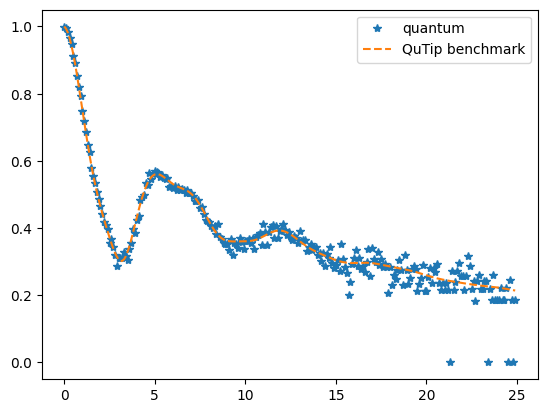

In [ ]:
# initial state in the dilated space
rho0_dilated = np.concatenate((vec_rho0,np.zeros(ndvr**2)))

# Adjust Prob_qc size to match nsteps (250)
Prob_qc = np.zeros(nsteps,dtype=np.float64)

#aersim=AerSimulator(method='statevector')
aersim=AerSimulator()
shots = 10000
for i in range(nsteps):
  if(i%10==0):print('istep',i)
  qr = QuantumRegister(nsite*2+1) # Create a quantum register
  cr = ClassicalRegister(nsite*2+1) # Create a classical register to store
  qc = QuantumCircuit(qr, cr) # Combine the quantum and classical registers to
                              # Initialize the quantum circuit with the initial state
  qc.initialize(rho0_dilated, qr)

  # Dilated propagator
  U_G, norm = dilate(Gprop[i])

  # Create a custom unitary operator with the dilated propagator
  U_G_op = Operator(U_G)

  # Apply the unitary operator to the quantum circuit's qubits
  qc.unitary(U_G_op, qr)

  qc.measure(qr, cr)

  counts1 = aersim.run(qc,shots=shots).result().get_counts()
  if '0011011' in counts1:
    aa = np.sqrt(counts1['0011011']/shots)*norm
    #print(aa)
    Prob_qc[i] = np.sqrt(aa)

plt.plot(time,Prob_qc,'*',label="quantum")
plt.plot(time,Prob,'--',label="QuTip benchmark")
plt.legend()

Quantum simulation of the Lindbladian dynamics of the spin-chain model system
using a quantum device simulator (blue stars) as compared to those obtained by a digital
computer simulation with QuTip